INICIANDO PIPELINE DE ANÁLISE DE RISCO DE CRÉDITO...

Aguardando seleção do arquivo... (Verifique se uma nova janela abriu na sua barra de tarefas).

=== ANÁLISE DE QUALIDADE: BASE BRUTA (PRÉ-LIMPEZA) ===
Total de Linhas: 32581 | Total de Colunas: 12

--- Valores Ausentes Encontrados ---
person_emp_length     895
loan_int_rate        3116
dtype: int64

[*] Base enriquecida salva com sucesso em: 'ApexBank_Carteira_Enriquecida_BI.csv'


=== ANÁLISE DE QUALIDADE: BASE TRATADA (PÓS-LIMPEZA) ===
Total de Linhas: 32409 | Total de Colunas: 17

✓ Nenhum valor ausente encontrado. Base limpa!


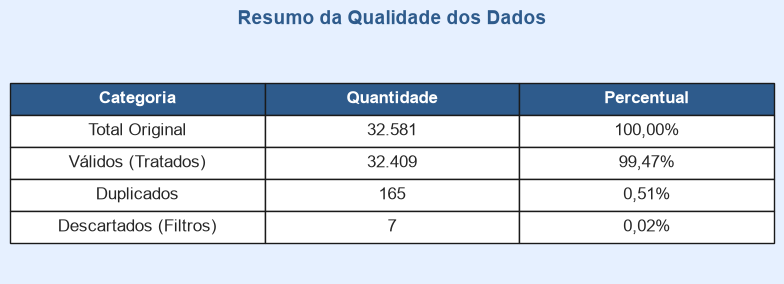


=== 1. TESTES NUMÉRICOS (Mann-Whitney) ===
➤ PERSON_AGE | p-valor: 5.2097e-10 | Efeito (r): 0.0344
➤ PERSON_INCOME | p-valor: 0.0000e+00 | Efeito (r): 0.2721
➤ LOAN_PERCENT_INCOME | p-valor: 0.0000e+00 | Efeito (r): 0.3163
➤ PERSON_EMP_LENGTH | p-valor: 3.9108e-67 | Efeito (r): 0.0957

=== 2. TESTES CATEGÓRICOS (Qui-Quadrado) ===
➤ DTI_ALERT | Estatística Qui²: 5969.05 | p-valor: 0.0000e+00 | V de Cramér: 0.4292
➤ CB_PERSON_DEFAULT_ON_FILE | Estatística Qui²: 1040.12 | p-valor: 3.4193e-228 | V de Cramér: 0.1791
➤ PERSON_HOME_OWNERSHIP | Estatística Qui²: 1893.77 | p-valor: 0.0000e+00 | V de Cramér: 0.2417

=== 3. INTERVALOS DE CONFIANÇA (Wilson - 95%) ===
Taxa Geral da Carteira : 21.87%  [IC 95%: 21.42% a 22.32%]
DTI > 30% (Alto Risco)   : 70.43%  [IC 95%: 68.96% a 71.86%]
>50 anos + Reforma do Lar: 47.06%  [IC 95%: 26.17% a 69.04%]
Grau G                   : 98.44%  [IC 95%: 91.67% a 99.72%]


In [4]:
# ==============================================================================
# PIPELINE COMPLETO E ORIGINAL - ANÁLISE DE RISCO DE CRÉDITO (APEXBANK)
# ==============================================================================

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import tkinter as tk
from tkinter import filedialog

# ==========================================
# 1. CONFIGURAÇÕES E SELEÇÃO VISUAL DE ARQUIVO
# ==========================================
OUTPUT_FILE = 'ApexBank_Carteira_Enriquecida_BI.csv'
sns.set_theme(style="whitegrid")

def selecionar_arquivo_visualmente() -> str:
    """Abre uma janela nativa do sistema operacional para seleção do arquivo."""
    print("Aguardando seleção do arquivo... (Verifique se uma nova janela abriu na sua barra de tarefas).")
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    
    caminho = filedialog.askopenfilename(
        title="Selecione o arquivo credit_risk_dataset.csv",
        filetypes=[("Arquivos CSV", "*.csv"), ("Todos os arquivos", "*.*")]
    )
    
    root.destroy()
    
    if not caminho:
        raise FileNotFoundError("\n[ERRO] A seleção de arquivo foi cancelada.")
        
    return caminho

def carregar_dados_absolutos(caminho: str) -> pd.DataFrame:
    try:
        return pd.read_csv(caminho)
    except Exception as e:
        raise RuntimeError(f"Erro ao tentar ler o arquivo: {str(e)}")

# ==========================================
# 2. PIPELINE DE PREPARAÇÃO DOS DADOS (CORRIGIDO)
# ==========================================
def limpar_e_enriquecer_dados(df_raw):
    """Aplica todas as regras de negócio de limpeza, imputação e criação de variáveis."""
    df_clean = df_raw.copy() 
    
    # 1. Limpeza Básica
    df_clean = df_clean.drop_duplicates()
    df_clean = df_clean[df_clean['person_age'] < 100]
    
    # 2. Imputação (DEVE ACONTECER ANTES DO FILTRO RELACIONAL)
    df_clean['loan_int_rate'] = df_clean.groupby('loan_grade')['loan_int_rate'].transform(lambda x: x.fillna(x.median()))
    df_clean['person_emp_length'] = df_clean['person_emp_length'].fillna(df_clean['person_emp_length'].median())
    
    # 3. Filtro Relacional
    df_clean = df_clean[df_clean['person_emp_length'] <= (df_clean['person_age'] - 14)]
    df_clean = df_clean.reset_index(drop=True)
    
    # 4. Engenharia de Recursos (Categorização)
    df_clean['age_group'] = pd.cut(
        df_clean['person_age'], bins=[0, 25, 35, 50, 150], 
        labels=['Até 25 anos', '26 a 35 anos', '36 a 50 anos', 'Mais de 50 anos']
    )
    df_clean['emp_length_group'] = pd.cut(
        df_clean['person_emp_length'], bins=[-1, 2, 5, 10, 150], 
        labels=['Até 2 anos', '2 a 5 anos', '5 a 10 anos', 'Mais de 10 anos']
    )
    
    df_clean['dti_risk_alert'] = np.where(df_clean['loan_percent_income'] > 0.30, 'Alto Risco', 'Risco Sob Controle')
    df_clean['dti_alert'] = df_clean['loan_percent_income'] > 0.30 
    df_clean['loan_status_label'] = df_clean['loan_status'].map({0: 'Adimplente', 1: 'Inadimplente (Default)'})
    
    return df_clean

# ==========================================
# 3. ANÁLISE DA ESTRUTURA E QUALIDADE (TABELA VISUAL)
# ==========================================
def relatorio_qualidade_dados(df, nome_base="Dataset"):
    """Exibe um resumo da estrutura, tipos de dados e identifica valores ausentes."""
    print(f"\n=== ANÁLISE DE QUALIDADE: {nome_base.upper()} ===")
    print(f"Total de Linhas: {df.shape[0]} | Total de Colunas: {df.shape[1]}\n")
    
    nulos = df.isnull().sum()
    if nulos.sum() > 0:
        print("--- Valores Ausentes Encontrados ---")
        print(nulos[nulos > 0])
    else:
        print("✓ Nenhum valor ausente encontrado. Base limpa!")
    print("="*50)

def gerar_tabela_imagem(df_raw: pd.DataFrame, df_tratado: pd.DataFrame):
    """Gera a tabela visual do resumo de governança com formatação PT-BR."""
    total = len(df_raw)
    duplicados = len(df_raw) - len(df_raw.drop_duplicates())
    validos = len(df_tratado)
    descartados = total - validos - duplicados
    
    dados = [
        ['Total Original', f"{total:,}".replace(',', '.'), "100,00%"],
        ['Válidos (Tratados)', f"{validos:,}".replace(',', '.'), f"{(validos/total)*100:.2f}".replace('.', ',') + "%"],
        ['Duplicados', f"{duplicados:,}".replace(',', '.'), f"{(duplicados/total)*100:.2f}".replace('.', ',') + "%"],
        ['Descartados (Filtros)', f"{descartados:,}".replace(',', '.'), f"{(descartados/total)*100:.2f}".replace('.', ',') + "%"]
    ]
    
    fig, ax = plt.subplots(figsize=(8, 3))
    fig.patch.set_facecolor('#E6F0FF') 
    ax.set_facecolor('#E6F0FF')
    ax.axis('off')
    
    tabela = ax.table(
        cellText=dados, 
        colLabels=['Categoria', 'Quantidade', 'Percentual'], 
        loc='center', 
        cellLoc='center'
    )
    
    tabela.scale(1, 2)
    tabela.set_fontsize(12)
    
    for (row, col), cell in tabela.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('#2E5B8C')
        else:
            cell.set_facecolor('white')

    plt.title('Resumo da Qualidade dos Dados', fontsize=14, fontweight='bold', pad=20, color='#2E5B8C')
    plt.tight_layout()
    plt.show()

# ==========================================
# 4. FUNÇÕES ESTATÍSTICAS
# ==========================================
def testar_numericas_mann_whitney(df, col):
    g0 = df[df['loan_status'] == 0][col].dropna()
    g1 = df[df['loan_status'] == 1][col].dropna()
    u_stat, p_valor = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    n1, n2 = len(g0), len(g1)
    mean_u = (n1 * n2) / 2
    sd_u = np.sqrt((n1 * n2 * (n1 + n2 + 1)) / 12)
    z_stat = (u_stat - mean_u) / sd_u
    r_effect = abs(z_stat) / np.sqrt(n1 + n2)
    
    print(f"➤ {col.upper()} | p-valor: {p_valor:.4e} | Efeito (r): {r_effect:.4f}")

def testar_categoricas_qui_quadrado(df, col):
    tabela = pd.crosstab(df[col], df['loan_status'])
    chi2, p_valor, _, _ = stats.chi2_contingency(tabela)
    
    n = tabela.sum().sum()
    min_dim = min(tabela.shape) - 1
    v_cramer = np.sqrt(chi2 / (n * min_dim))
    
    print(f"➤ {col.upper()} | Estatística Qui²: {chi2:.2f} | p-valor: {p_valor:.4e} | V de Cramér: {v_cramer:.4f}")

def calcular_ic_wilson(sucessos, total, confianca=0.95):
    if total == 0: return 0, 0, 0
    p = sucessos / total
    z = stats.norm.ppf(1 - (1 - confianca) / 2)
    denominador = 1 + (z**2 / total)
    centro = p + (z**2 / (2 * total))
    margem_erro = z * np.sqrt((p * (1 - p) / total) + (z**2 / (4 * total**2)))
    return p, (centro - margem_erro) / denominador, (centro + margem_erro) / denominador

def executar_todos_os_testes(df):
    """Orquestra a execução da bateria de testes estatísticos."""
    print("\n=== 1. TESTES NUMÉRICOS (Mann-Whitney) ===")
    for col in ['person_age', 'person_income', 'loan_percent_income', 'person_emp_length']:
        testar_numericas_mann_whitney(df, col)

    print("\n=== 2. TESTES CATEGÓRICOS (Qui-Quadrado) ===")
    for col in ['dti_alert', 'cb_person_default_on_file', 'person_home_ownership']:
        testar_categoricas_qui_quadrado(df, col)

    print("\n=== 3. INTERVALOS DE CONFIANÇA (Wilson - 95%) ===")
    p_geral, ic_b_geral, ic_a_geral = calcular_ic_wilson(df['loan_status'].sum(), len(df))
    print(f"Taxa Geral da Carteira : {p_geral*100:.2f}%  [IC 95%: {ic_b_geral*100:.2f}% a {ic_a_geral*100:.2f}%]")
    
    df_dti_alto = df[df['dti_alert'] == True]
    if len(df_dti_alto) > 0:
        p_ar, ic_b_ar, ic_a_ar = calcular_ic_wilson(df_dti_alto['loan_status'].sum(), len(df_dti_alto))
        print(f"DTI > 30% (Alto Risco)   : {p_ar*100:.2f}%  [IC 95%: {ic_b_ar*100:.2f}% a {ic_a_ar*100:.2f}%]")

    df_idoso_reforma = df[(df['person_age'] > 50) & (df['loan_intent'] == 'HOMEIMPROVEMENT')]
    if len(df_idoso_reforma) > 0:
        p_id, ic_b_id, ic_a_id = calcular_ic_wilson(df_idoso_reforma['loan_status'].sum(), len(df_idoso_reforma))
        print(f">50 anos + Reforma do Lar: {p_id*100:.2f}%  [IC 95%: {ic_b_id*100:.2f}% a {ic_a_id*100:.2f}%]")

    df_grau_g = df[df['loan_grade'] == 'G']
    if len(df_grau_g) > 0:
        p_g, ic_b_g, ic_a_g = calcular_ic_wilson(df_grau_g['loan_status'].sum(), len(df_grau_g))
        print(f"Grau G                   : {p_g*100:.2f}%  [IC 95%: {ic_b_g*100:.2f}% a {ic_a_g*100:.2f}%]")

# ==========================================
# 5. EXECUÇÃO ORQUESTRADA
# ==========================================
if __name__ == "__main__":
    print("INICIANDO PIPELINE DE ANÁLISE DE RISCO DE CRÉDITO...\n")

    # 1. Carrega via Interface Gráfica
    caminho_escolhido = selecionar_arquivo_visualmente()
    df_bruto = carregar_dados_absolutos(caminho_escolhido)
    
    # 2. Relatório Bruto
    relatorio_qualidade_dados(df_bruto, "Base Bruta (Pré-Limpeza)")

    # 3. Limpa, enriquece e salva checkpoint
    df_tratado = limpar_e_enriquecer_dados(df_bruto)
    df_tratado.to_csv(OUTPUT_FILE, index=False)
    print(f"\n[*] Base enriquecida salva com sucesso em: '{OUTPUT_FILE}'\n")

    # 4. Relatório Tratado
    relatorio_qualidade_dados(df_tratado, "Base Tratada (Pós-Limpeza)")
    
    # 5. Renderiza a Tabela de Qualidade Visual
    gerar_tabela_imagem(df_bruto, df_tratado)

    # 6. Audita as estatísticas do Word
    executar_todos_os_testes(df_tratado)

Gráfico 1 – Distribuição do Status dos Empréstimos

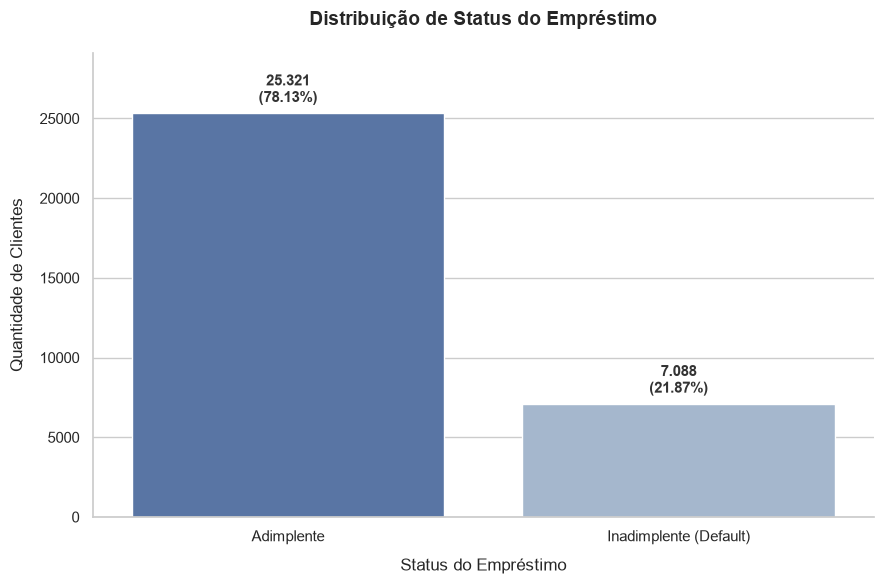

In [23]:
# ==============================================================================
# 6.1. VISUALIZAÇÃO UNIVARIADA: DISTRIBUIÇÃO DA VARIÁVEL ALVO (STATUS)
# ==============================================================================

def plotar_distribuicao_status(df: pd.DataFrame) -> None:
    """
    Gera a representação gráfica da volumetria de operações de crédito,
    segregando a carteira entre classes de adimplência e default.

    Args:
        df (pd.DataFrame): Base de dados processada contendo as features alvo.
    """
    # Configuração do grid de renderização
    plt.figure(figsize=(9, 6))
    
    # Validação e mapeamento do atributo qualitativo nominal
    if 'loan_status_label' not in df.columns:
        df['loan_status_label'] = df['loan_status'].map({
            0: 'Adimplente', 
            1: 'Inadimplente (Default)'
        })
        
    # Agregação volumétrica e cálculo de distribuição de frequência
    df_counts = df['loan_status_label'].value_counts().reset_index()
    df_counts.columns = ['status', 'quantidade']
    df_counts['percentual'] = (df_counts['quantidade'] / df_counts['quantidade'].sum()) * 100
    
    # Instanciação do objeto gráfico
    ax = sns.barplot(
        x='status', 
        y='quantidade', 
        data=df_counts, 
        palette=['#4C72B0', '#9EB6D4'], 
        hue='status', 
        legend=False
    )
    
    # Estilização estrutural (remoção de bordas top/right)
    sns.despine()
    
    # Iteração para rotulagem paramétrica de anotações (Volume + Representatividade)
    for p in ax.patches:
        height = p.get_height()
        pct = df_counts.loc[df_counts['quantidade'] == height, 'percentual'].values[0]
        
        # Formatação numérica ajustada ao padrão local
        texto = f"{int(height):,}\n({pct:.2f}%)".replace(',', '.')
        
        ax.annotate(
            texto, 
            (p.get_x() + p.get_width() / 2., height),
            ha='center', 
            va='bottom', 
            fontsize=11, 
            fontweight='bold', 
            color='#333333', 
            xytext=(0, 5), 
            textcoords='offset points'
        )

    # Definição de propriedades tipográficas e titulação
    plt.title('Distribuição de Status do Empréstimo', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Status do Empréstimo', fontsize=12, labelpad=10)
    plt.ylabel('Quantidade de Clientes', fontsize=12, labelpad=10)
    
    # Redimensionamento escalar do limite do eixo Y para acomodação de rótulos
    plt.ylim(0, df_counts['quantidade'].max() * 1.15) 
    plt.tight_layout()
    plt.show()

# ==============================================================================
# Execução do Módulo Visual
# ==============================================================================
plotar_distribuicao_status(df_tratado)


Gráfico 2 - Análise de correlação entre variáveis numéricas

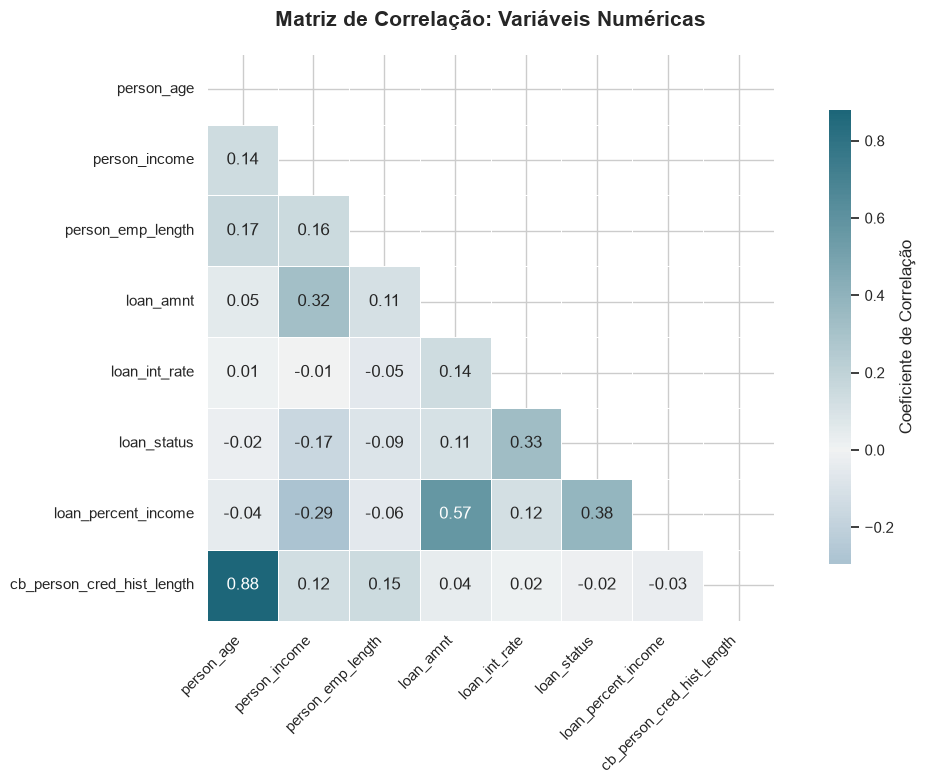

In [24]:
# ==============================================================================
# 6.2. VISUALIZAÇÃO MULTIVARIADA: MATRIZ DE CORRELAÇÃO LINEAR (HEATMAP)
# ==============================================================================

def plotar_matriz_correlacao(df: pd.DataFrame) -> None:
    """
    Calcula e renderiza a matriz de correlação de Pearson para os atributos numéricos contínuos.
    Emprega o mascaramento do triângulo superior para mitigar redundância visual e utiliza
    uma escala de cores divergente adaptada à paleta institucional do projeto.

    Args:
        df (pd.DataFrame): Base de dados processada contendo os atributos numéricos.
    """
    # Configuração do plano de fundo e proporção da figura
    plt.figure(figsize=(12, 8))
    
    # Extração das *features* quantitativas e cálculo da matriz de correlação linear
    corr = df.select_dtypes(include=['number']).corr()
    
    # Construção da matriz de mascaramento para ocultação do triângulo superior
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    # Parametrização do mapa de cores (colormap) divergente (espectro frio/azul)
    cmap = sns.diverging_palette(240, 220, s=90, l=40, n=20, as_cmap=True)
    
    # Renderização da matriz de calor com injeção escalar nos rótulos
    ax = sns.heatmap(
        corr, 
        mask=mask, 
        annot=True, 
        fmt=".2f", 
        cmap=cmap, 
        center=0,
        square=True, 
        linewidths=.5, 
        cbar_kws={"shrink": .8, "label": "Coeficiente de Correlação"}
    )
    
    # Parametrização tipográfica de título e eixos espaciais
    plt.title('Matriz de Correlação: Variáveis Numéricas', fontsize=15, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right')
    
    # Otimização paramétrica das margens da figura
    plt.tight_layout()
    plt.show()

# ==============================================================================
# Execução do Módulo Visual
# ==============================================================================
plotar_matriz_correlacao(df_tratado)

Gráfico 3 – Distribuição da Renda dos Clientes por Status do Empréstimo

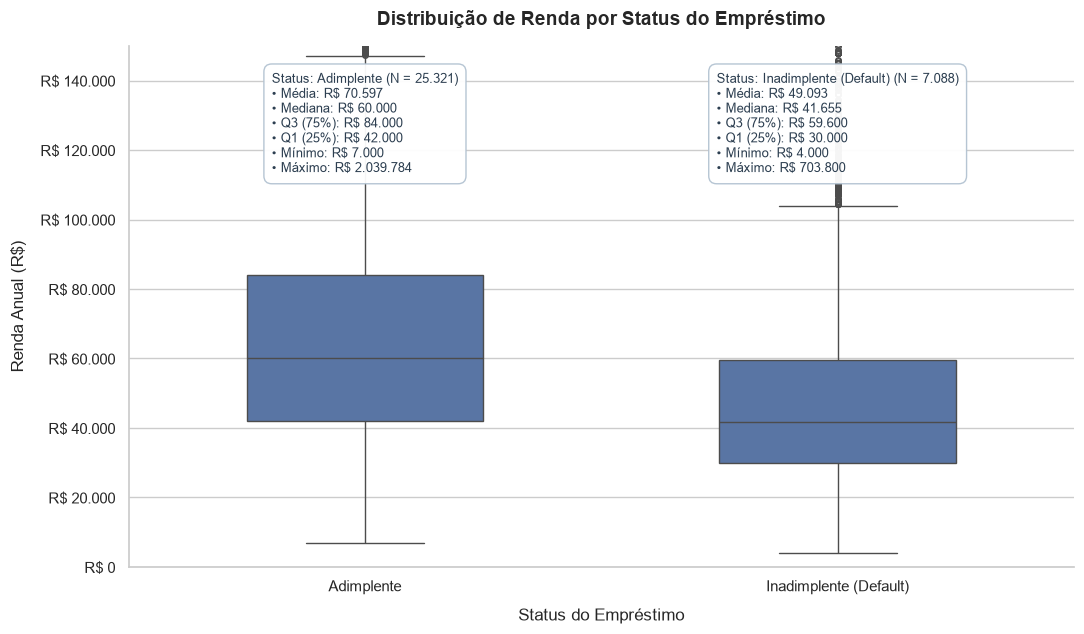

In [25]:
# ==============================================================================
# 6.3. VISUALIZAÇÃO BIVARIADA: DISTRIBUIÇÃO DE RENDA POR STATUS (BOXPLOT)
# ==============================================================================

def plotar_renda_por_status(df: pd.DataFrame) -> None:
    """
    Gera um diagrama de caixa (boxplot) relacionando a renda bruta anual (person_income)
    com o status final da operação de crédito. Inclui a renderização de anotações
    textuais responsivas contendo estatísticas descritivas sumarizadas da distribuição.

    Args:
        df (pd.DataFrame): Base de dados processada contendo os atributos alvo.
    """
    # Configuração do plano de fundo e dimensões da figura
    plt.figure(figsize=(11, 6.5))

    # Renderização do diagrama de caixa com parametrização da dispersão interquartílica
    ax = sns.boxplot(
        x='loan_status_label', 
        y='person_income', 
        data=df, 
        color='#4C72B0', 
        width=0.5,
        fliersize=4
    )
    
    # Otimização visual e redução de ruído não-essencial (Maximização do Data-Ink Ratio)
    sns.despine()

    # Ancoragem do limite superior do eixo Y para mitigação visual de outliers extremos de renda
    limite_y_max = 150000
    plt.ylim(0, limite_y_max)
    ax.set_yticks(range(0, limite_y_max + 10000, 20000))

    # Formatação monetária paramétrica do eixo contínuo (padrão local BRL)
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, pos: f"R$ {x:,.0f}".replace(",", "."))
    )

    # Definição do ponto de ancoragem vertical escalar para as caixas de estatísticas
    ancora_texto_y = limite_y_max * 0.95

    # Iteração sobre as classes para extração e anotação das métricas de tendência central e dispersão
    for i, status in enumerate(['Adimplente', 'Inadimplente (Default)']):
        subset = df[df['loan_status_label'] == status]['person_income'].dropna()
        
        # Estruturação geométrica e formatação do report descritivo por classe
        texto_resumo = (
            f"Status: {status} (N = {len(subset):,})\n"
            f"• Média: R$ {subset.mean():,.0f}\n"
            f"• Mediana: R$ {subset.median():,.0f}\n"
            f"• Q3 (75%): R$ {subset.quantile(0.75):,.0f}\n"
            f"• Q1 (25%): R$ {subset.quantile(0.25):,.0f}\n"
            f"• Mínimo: R$ {subset.min():,.0f}\n"
            f"• Máximo: R$ {subset.max():,.0f}"
        ).replace(",", ".")
        
        # Inserção da caixa delimitadora (bounding box) contendo o sumário descritivo
        ax.text(
            x=i, 
            y=ancora_texto_y, 
            s=texto_resumo,
            ha='center', 
            va='top', 
            multialignment='left',
            fontsize=9.5, 
            color='#2C3E50',
            bbox=dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor="#B2C2D1", alpha=0.95)
        )

    # Parametrização tipográfica de titulação e nomenclatura bidimensional
    plt.title('Distribuição de Renda por Status do Empréstimo', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Status do Empréstimo', fontsize=12, labelpad=10)
    plt.ylabel('Renda Anual (R$)', fontsize=12, labelpad=10)

    # Otimização paramétrica de margens da figura
    plt.tight_layout()
    plt.show()

# ==============================================================================
# Execução do Módulo Visual
# ==============================================================================
plotar_renda_por_status(df_tratado)

Gráfico 4 – Percentual da Renda Comprometido por Status do Empréstimo

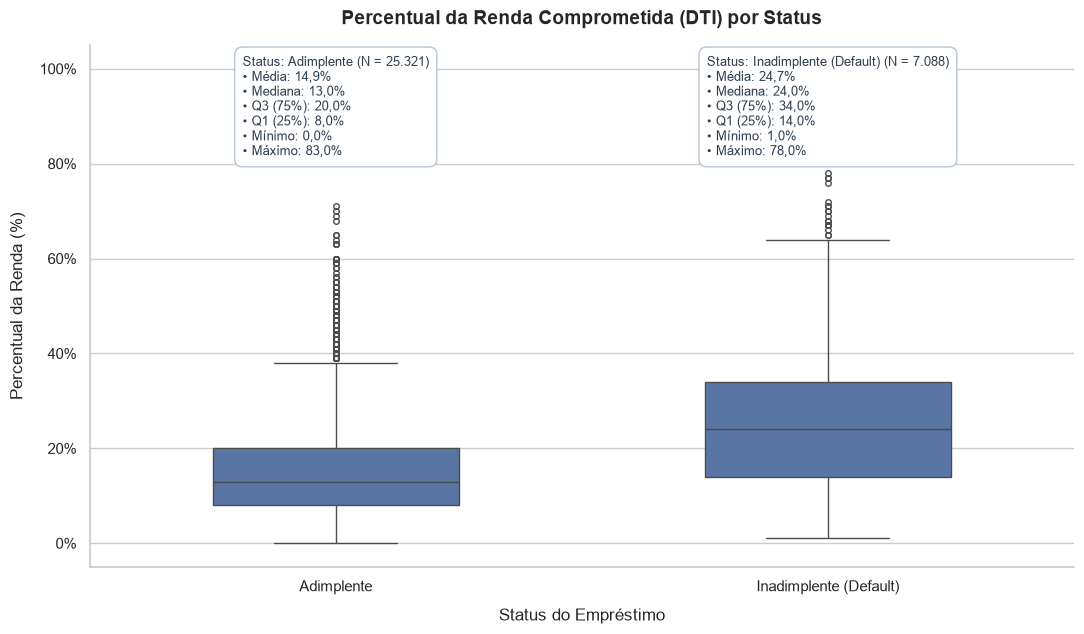

In [27]:
# ==============================================================================
# 6.4. VISUALIZAÇÃO BIVARIADA: COMPROMETIMENTO DE RENDA (DTI) POR STATUS
# ==============================================================================

def plotar_dti_por_status(df: pd.DataFrame) -> None:
    """
    Gera um diagrama de caixa (boxplot) relacionando o comprometimento de renda
    (Debt-to-Income - DTI) com o status final da operação de crédito. Inclui
    a renderização de métricas descritivas sumarizadas e formatação percentual paramétrica.

    Args:
        df (pd.DataFrame): Base de dados processada contendo os atributos alvo.
    """
    # Configuração do plano de fundo e dimensões da figura
    plt.figure(figsize=(11, 6.5))
    
    # Renderização do diagrama de caixa com parametrização da dispersão interquartílica
    ax = sns.boxplot(
        x='loan_status_label', 
        y='loan_percent_income', 
        data=df, 
        color='#4C72B0', 
        width=0.5, 
        fliersize=4
    )
    
    # Otimização visual e redução de ruído não-essencial (Maximização do Data-Ink Ratio)
    sns.despine()

    # Parametrização escalar do eixo Y para delimitação estrita (0 a 100% com margem de respiro)
    limite_y_max = 1.05
    plt.ylim(-0.05, limite_y_max)
    
    # Formatação paramétrica do eixo contínuo para exibição percentual absoluta
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, pos: f"{x * 100:.0f}%")
    )

    # Definição do ponto de ancoragem vertical escalar para as caixas de estatísticas descritivas
    ancora_texto_y = limite_y_max * 0.98

    # Função auxiliar encapsulada para formatação percentual no padrão local (PT-BR)
    def formatar_percentual(valor: float) -> str: 
        return f"{valor * 100:.1f}%".replace('.', ',')

    # Iteração sobre as classes para extração e anotação das métricas de tendência central e dispersão
    for i, status in enumerate(['Adimplente', 'Inadimplente (Default)']):
        subset = df[df['loan_status_label'] == status]['loan_percent_income'].dropna()
        
        # Formatação paramétrica de volumetria absoluta
        n_formatado = f"{len(subset):,}".replace(",", ".")
        
        # Estruturação geométrica e formatação do report descritivo por classe
        texto_resumo = (
            f"Status: {status} (N = {n_formatado})\n"
            f"• Média: {formatar_percentual(subset.mean())}\n"
            f"• Mediana: {formatar_percentual(subset.median())}\n"
            f"• Q3 (75%): {formatar_percentual(subset.quantile(0.75))}\n"
            f"• Q1 (25%): {formatar_percentual(subset.quantile(0.25))}\n"
            f"• Mínimo: {formatar_percentual(subset.min())}\n"
            f"• Máximo: {formatar_percentual(subset.max())}"
        )
        
        # Inserção da caixa delimitadora (bounding box) contendo o sumário descritivo
        ax.text(
            x=i, 
            y=ancora_texto_y, 
            s=texto_resumo,
            ha='center', 
            va='top', 
            multialignment='left',
            fontsize=9.5, 
            color='#2C3E50',
            bbox=dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor="#B2C2D1", alpha=0.95)
        )

    # Parametrização tipográfica de titulação e nomenclatura bidimensional
    plt.title('Percentual da Renda Comprometida (DTI) por Status', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Status do Empréstimo', fontsize=12, labelpad=10)
    plt.ylabel('Percentual da Renda (%)', fontsize=12, labelpad=10)
    
    # Otimização paramétrica de margens da figura
    plt.tight_layout()
    plt.show()

# ==============================================================================
# Execução do Módulo Visual
# ==============================================================================
plotar_dti_por_status(df_tratado)

Gráfico 5 - Relação entre Comprometimento de Renda (DTI) e Inadimplência

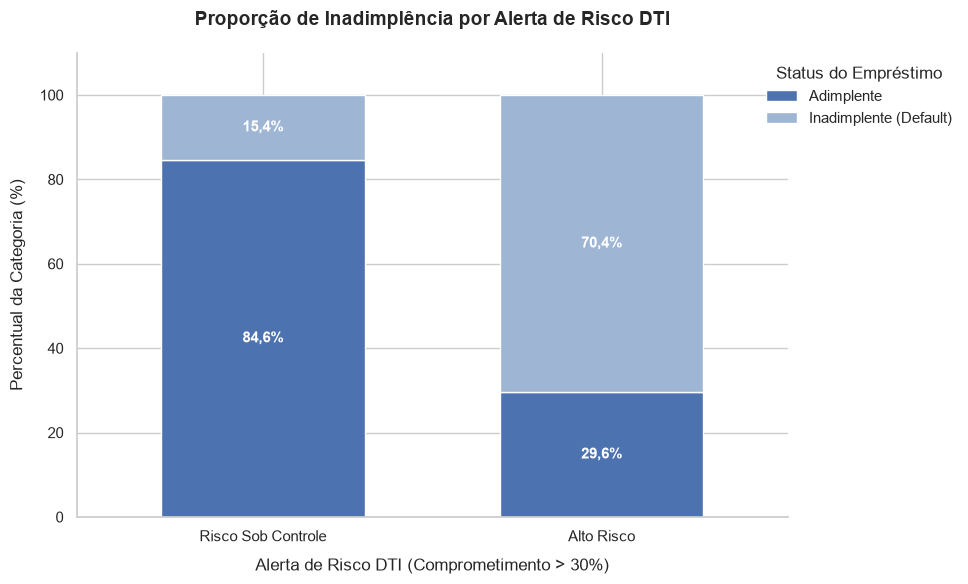

In [28]:
# ==============================================================================
# 6.5. VISUALIZAÇÃO BIVARIADA: PROPORÇÃO DE INADIMPLÊNCIA POR ALERTA DTI
# ==============================================================================

def plotar_risco_dti(df: pd.DataFrame) -> None:
    """
    Gera uma representação gráfica em barras empilhadas (stacked bar chart) para
    avaliar a proporção de inadimplência segmentada por faixas críticas de
    comprometimento de renda (DTI > 30%).

    Args:
        df (pd.DataFrame): Base de dados processada contendo as variáveis alvo.
    """
    # Isolamento do dataframe para aplicação de transformações temporárias
    df_temp = df.copy()
    
    # Derivação do atributo categórico de risco baseado na parametrização do DTI
    df_temp['risco_dti'] = df_temp['loan_percent_income'].apply(
        lambda x: 'Alto Risco' if x > 0.30 else 'Risco Sob Controle'
    )
    
    # Cálculo da matriz de contingência com normalização relativa por linha (percentual)
    freq_relativa = pd.crosstab(
        df_temp['risco_dti'], 
        df_temp['loan_status_label'], 
        normalize='index'
    ) * 100
    
    # Ordenação estrita das classes para preservação da escala de cores e legibilidade
    freq_relativa = freq_relativa[['Adimplente', 'Inadimplente (Default)']]
    freq_relativa = freq_relativa.reindex(['Risco Sob Controle', 'Alto Risco'])
    
    # Instanciação do objeto gráfico empilhado
    ax = freq_relativa.plot(
        kind='bar', 
        stacked=True, 
        figsize=(10, 6), 
        color=['#4C72B0', '#9EB6D4'], 
        width=0.6
    )
    
    # Otimização visual e remoção de bordas espaciais limitantes (Top/Right)
    sns.despine()
    
    # Parametrização espacial do eixo X e Y (alocação de margem de respiro superior)
    plt.xticks(rotation=0)
    plt.ylim(0, 110) 
    
    # Iteração sobre os contêineres para injeção e formatação PT-BR dos rótulos proporcionais
    for container in ax.containers:
        # Extração e conversão de valores flutuantes para string padronizada com vírgula
        rotulos = [f"{valor:.1f}%".replace('.', ',') if valor > 0 else "" for valor in container.datavalues]
        
        ax.bar_label(
            container, 
            labels=rotulos,
            label_type='center', 
            color='white', 
            fontweight='bold', 
            fontsize=11
        )
        
    # Parametrização tipográfica de titulação e eixos dimensionais
    plt.title('Proporção de Inadimplência por Alerta de Risco DTI', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Alerta de Risco DTI (Comprometimento > 30%)', fontsize=12, labelpad=10)
    plt.ylabel('Percentual da Categoria (%)', fontsize=12, labelpad=10)
    
    # Reposicionamento dinâmico da legenda externa para mitigação de sobreposição
    plt.legend(
        title='Status do Empréstimo', 
        frameon=False, 
        loc='upper right', 
        bbox_to_anchor=(1.25, 1)
    )
    
    # Otimização paramétrica das margens da figura
    plt.tight_layout()
    plt.show()

# ==============================================================================
# Execução do Módulo Visual
# ==============================================================================
plotar_risco_dti(df_tratado)

Gráfico 6 – Tempo de Emprego por Status do Empréstimo

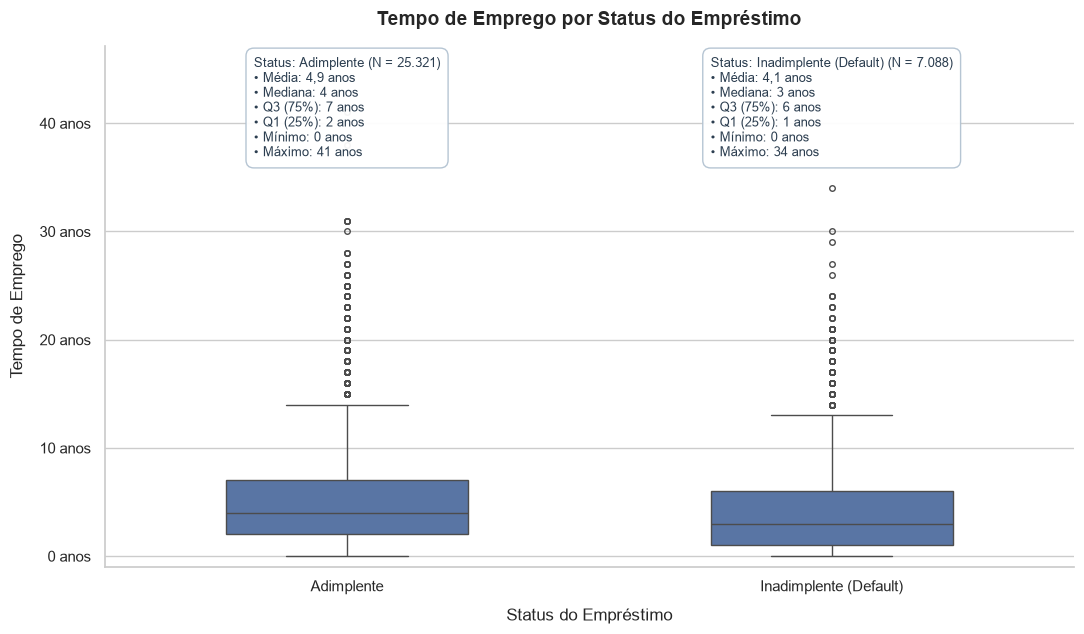

In [29]:
# ==============================================================================
# 6.6. VISUALIZAÇÃO BIVARIADA: TEMPO DE EMPREGO POR STATUS (BOXPLOT)
# ==============================================================================

def plotar_tempo_emprego_por_status(df: pd.DataFrame) -> None:
    """
    Gera um diagrama de caixa (boxplot) relacionando o tempo de vínculo empregatício
    (em anos) com o status final da operação de crédito. Renderiza anotações textuais
    responsivas contendo estatísticas descritivas sumarizadas da distribuição.

    Args:
        df (pd.DataFrame): Base de dados processada contendo os atributos alvo.
    """
    # Configuração do plano de fundo e dimensões da figura
    plt.figure(figsize=(11, 6.5))
    
    # Renderização do diagrama de caixa com parametrização da dispersão interquartílica
    ax = sns.boxplot(
        x='loan_status_label', 
        y='person_emp_length', 
        data=df, 
        color='#4C72B0', 
        width=0.5, 
        fliersize=4
    )
    
    # Otimização visual e redução de ruído não-essencial (Maximização do Data-Ink Ratio)
    sns.despine()

    # Escalonamento dinâmico do limite superior do eixo Y para acomodação das métricas
    limite_y_max = df['person_emp_length'].max() * 1.15
    plt.ylim(-1, limite_y_max)
    
    # Formatação paramétrica do eixo contínuo para explicitação da unidade de medida
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, pos: f"{int(x)} anos" if x >= 0 else "")
    )

    # Definição do ponto de ancoragem vertical escalar para as caixas de estatísticas descritivas
    ancora_texto_y = limite_y_max * 0.98

    # Iteração sobre as classes para extração e anotação das métricas de tendência central e dispersão
    for i, status in enumerate(['Adimplente', 'Inadimplente (Default)']):
        subset = df[df['loan_status_label'] == status]['person_emp_length'].dropna()
        
        # Formatação paramétrica de volumetria absoluta
        n_formatado = f"{len(subset):,}".replace(",", ".")
        
        # Estruturação geométrica e formatação do report descritivo por classe
        texto_resumo = (
            f"Status: {status} (N = {n_formatado})\n"
            f"• Média: {str(round(subset.mean(), 1)).replace('.', ',')} anos\n"
            f"• Mediana: {int(subset.median())} anos\n"
            f"• Q3 (75%): {int(subset.quantile(0.75))} anos\n"
            f"• Q1 (25%): {int(subset.quantile(0.25))} anos\n"
            f"• Mínimo: {int(subset.min())} anos\n"
            f"• Máximo: {int(subset.max())} anos"
        )
        
        # Inserção da caixa delimitadora (bounding box) contendo o sumário descritivo
        ax.text(
            x=i, 
            y=ancora_texto_y, 
            s=texto_resumo,
            ha='center', 
            va='top', 
            multialignment='left',
            fontsize=9.5, 
            color='#2C3E50',
            bbox=dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor="#B2C2D1", alpha=0.95)
        )

    # Parametrização tipográfica de titulação e nomenclatura bidimensional
    plt.title('Tempo de Emprego por Status do Empréstimo', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Status do Empréstimo', fontsize=12, labelpad=10)
    plt.ylabel('Tempo de Emprego', fontsize=12, labelpad=10)
    
    # Otimização paramétrica de margens da figura
    plt.tight_layout()
    plt.show()
    
# ==============================================================================
# Execução do Módulo Visual
# ==============================================================================
plotar_tempo_emprego_por_status(df_tratado)

Gráfico 7 – Taxa de Inadimplência por Tempo de Emprego

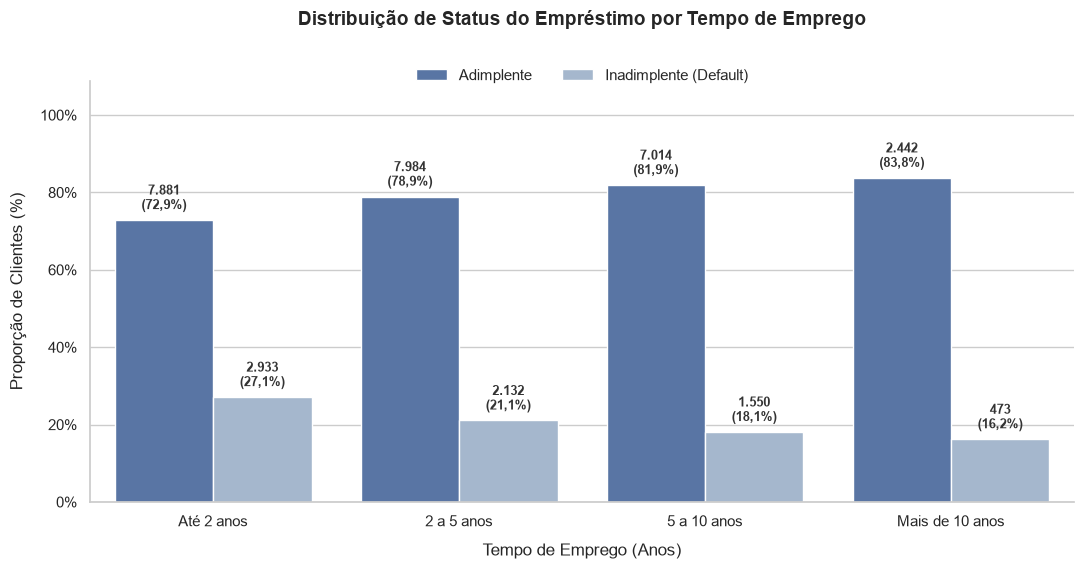

In [30]:
# ==============================================================================
# 6.7. VISUALIZAÇÃO MULTIVARIADA: STATUS DA OPERAÇÃO POR TEMPO DE EMPREGO
# ==============================================================================

def plotar_status_tempo_emprego(df: pd.DataFrame) -> None:
    """
    Gera um gráfico de barras agrupadas (grouped bar chart) para análise bivariada
    entre o tempo de vínculo empregatício categorizado (binning) e a proporção
    de adimplência/inadimplência da carteira.

    Args:
        df (pd.DataFrame): Base de dados processada contendo os atributos alvo.
    """
    # Configuração do plano de fundo e dimensões da figura
    plt.figure(figsize=(11, 6.5))
    
    # Isolamento do dataframe para transformações temporárias estruturais
    df_temp = df.copy()
    
    # Discretização (Binning) da variável contínua em faixas categóricas ordinais
    df_temp['emp_bins'] = pd.cut(
        df_temp['person_emp_length'].fillna(0), 
        bins=[-1, 2, 5, 10, 100], 
        labels=['Até 2 anos', '2 a 5 anos', '5 a 10 anos', 'Mais de 10 anos']
    )
    
    # Agregação volumétrica absoluta por faixa de emprego e status da operação
    df_grouped = df_temp.groupby(
        ['emp_bins', 'loan_status_label'], 
        observed=False
    ).size().reset_index(name='quantidade')
    
    # Computação da frequência relativa (percentual) intragrupo
    df_grouped['total_faixa'] = df_grouped.groupby('emp_bins')['quantidade'].transform('sum')
    df_grouped['percentual'] = (df_grouped['quantidade'] / df_grouped['total_faixa']) * 100
    
    # Mapeamento vetorial de ordenação para plotagem categórica
    ordem_x = ['Até 2 anos', '2 a 5 anos', '5 a 10 anos', 'Mais de 10 anos']
    ordem_hue = ['Adimplente', 'Inadimplente (Default)']
    
    # Instanciação e parametrização do objeto gráfico agrupado
    ax = sns.barplot(
        x='emp_bins', 
        y='percentual', 
        hue='loan_status_label', 
        data=df_grouped,
        order=ordem_x,
        hue_order=ordem_hue,
        palette=['#4C72B0', '#9EB6D4'], 
        dodge=True, 
        width=0.8
    )
    
    # Otimização visual e redução de ruído estrutural (Maximização do Data-Ink Ratio)
    sns.despine()
    
    # Formatação paramétrica do eixo Y para representação percentual absoluta
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:.0f}%"))
    
    # Escalonamento dinâmico do eixo Y para acomodação dos rótulos numéricos
    plt.ylim(0, df_grouped['percentual'].max() * 1.30)
    
    # Ordenação matricial estrita para garantir o alinhamento das anotações textuais com os polígonos (patches)
    df_grouped['emp_bins'] = pd.Categorical(df_grouped['emp_bins'], categories=ordem_x, ordered=True)
    df_grouped['loan_status_label'] = pd.Categorical(df_grouped['loan_status_label'], categories=ordem_hue, ordered=True)
    df_grouped = df_grouped.sort_values(by=['loan_status_label', 'emp_bins']).reset_index(drop=True)
    
    # Iteração sobre a topologia das barras para injeção de volumetria e taxa de conversão
    for p, (_, row) in zip(ax.patches, df_grouped.iterrows()):
        height = p.get_height()
        if height > 0:
            # Formatação PT-BR unificada: Ponto para milhar (volumetria) e vírgula para decimal (percentual)
            vol_formatado = f"{int(row['quantidade']):,}".replace(',', '.')
            pct_formatado = f"{height:.1f}%".replace('.', ',')
            texto = f"{vol_formatado}\n({pct_formatado})"
            
            ax.annotate(
                texto, 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', 
                va='bottom', 
                fontsize=9, 
                fontweight='bold', 
                color='#333333', 
                xytext=(0, 5), 
                textcoords='offset points'
            )

    # Parametrização tipográfica de titulação e reposicionamento dinâmico da legenda externa
    plt.title('Distribuição de Status do Empréstimo por Tempo de Emprego', fontsize=14, fontweight='bold', pad=40)
    plt.legend(
        title='', 
        frameon=False, 
        loc='upper center', 
        bbox_to_anchor=(0.5, 1.06), 
        ncol=2, 
        fontsize=11
    )
    
    # Configuração dos eixos dimensionais espaciais
    plt.xlabel('Tempo de Emprego (Anos)', fontsize=12, labelpad=10)
    plt.ylabel('Proporção de Clientes (%)', fontsize=12, labelpad=10)
    plt.xticks(rotation=0)
    
    # Otimização paramétrica da bounding box da figura para mitigar sobreposições topológicas
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()

# ==============================================================================
# Execução do Módulo Visual
# ==============================================================================
plotar_status_tempo_emprego(df_tratado)

Gráfico 8 - Análise da finalidade do empréstimo por status de pagamento

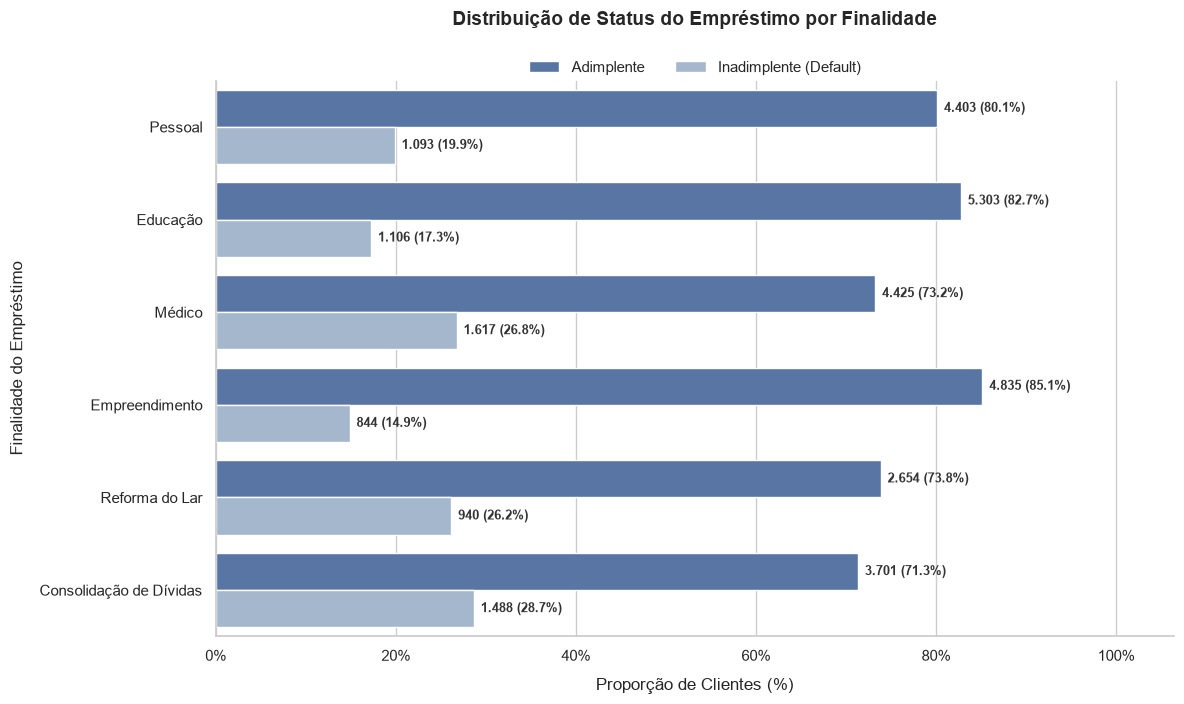

In [31]:
# ==========================================
# 6.8 GRÁFICO 8: STATUS POR FINALIDADE (Horizontal)
# ==========================================

def plotar_status_finalidade_horizontal(df):
    """
    Gráfico 8: Comparativo de Adimplentes e Inadimplentes 
    por Finalidade, em barras horizontais (Tons de Azul).
    """
    plt.figure(figsize=(12, 8))
    
    df_temp = df.copy()
    
    # Mapeamento para português
    traducao_intent = {
        'PERSONAL': 'Pessoal',
        'EDUCATION': 'Educação',
        'MEDICAL': 'Médico',
        'VENTURE': 'Empreendimento',
        'HOMEIMPROVEMENT': 'Reforma do Lar',
        'DEBTCONSOLIDATION': 'Consolidação de Dívidas'
    }
    df_temp['intent_pt'] = df_temp['loan_intent'].map(traducao_intent).fillna(df_temp['loan_intent'])
    
    # 1. Agrupamento: Contagem absoluta
    df_grouped = df_temp.groupby(['intent_pt', 'loan_status_label'], observed=False).size().reset_index(name='quantidade')
    
    # 2. Cálculo do percentual dentro de cada finalidade
    df_grouped['total_intent'] = df_grouped.groupby('intent_pt')['quantidade'].transform('sum')
    df_grouped['percentual'] = (df_grouped['quantidade'] / df_grouped['total_intent']) * 100
    
    # 3. Definição das ordens
    ordem_y = ['Pessoal', 'Educação', 'Médico', 'Empreendimento', 'Reforma do Lar', 'Consolidação de Dívidas']
    ordem_hue = ['Adimplente', 'Inadimplente (Default)']
    
    # 4. Plotagem Horizontal (x e y invertidos)
    ax = sns.barplot(
        x='percentual', 
        y='intent_pt', 
        hue='loan_status_label', 
        data=df_grouped,
        order=ordem_y,
        hue_order=ordem_hue,
        palette=['#4C72B0', '#9EB6D4'], # Azul forte e Azul suave
        dodge=True, 
        width=0.8
    )
    
    sns.despine()
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:.0f}%"))
    plt.xlim(0, df_grouped['percentual'].max() * 1.25)
    
    # 5. Ordenação para o loop de anotação
    df_grouped['intent_pt'] = pd.Categorical(df_grouped['intent_pt'], categories=ordem_y, ordered=True)
    df_grouped['loan_status_label'] = pd.Categorical(df_grouped['loan_status_label'], categories=ordem_hue, ordered=True)
    
    # CORREÇÃO CRÍTICA AQUI: O Seaborn desenha primeiro o HUE (Status), depois o Eixo Y.
    # Então a ordenação deve ser exatamente nessa ordem!
    df_grouped = df_grouped.sort_values(by=['loan_status_label', 'intent_pt']).reset_index(drop=True)
    
    # 6. Anotações (adaptadas para barras horizontais)
    for p, (_, row) in zip(ax.patches, df_grouped.iterrows()):
        width = p.get_width()
        if width > 0:
            # Posiciona o texto à direita da barra
            texto = f"{int(row['quantidade']):,} ({width:.1f}%)".replace(',', '.')
            ax.annotate(
                texto, 
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', 
                fontsize=9, fontweight='bold', color='#333333', 
                xytext=(5, 0), textcoords='offset points'
            )

    # 7. Títulos e Legenda
    plt.title('Distribuição de Status do Empréstimo por Finalidade', fontsize=14, fontweight='bold', pad=40)
    plt.legend(title='', frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.06), ncol=2, fontsize=11)
    
    plt.xlabel('Proporção de Clientes (%)', fontsize=12, labelpad=10)
    plt.ylabel('Finalidade do Empréstimo', fontsize=12, labelpad=10)
    
    # Ajuste final de layout
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()

# ------------------------------------------
# Execução
# ------------------------------------------
plotar_status_finalidade_horizontal(df_tratado)

Gráfico 9 – Taxa de Inadimplência por Tipo de Moradia

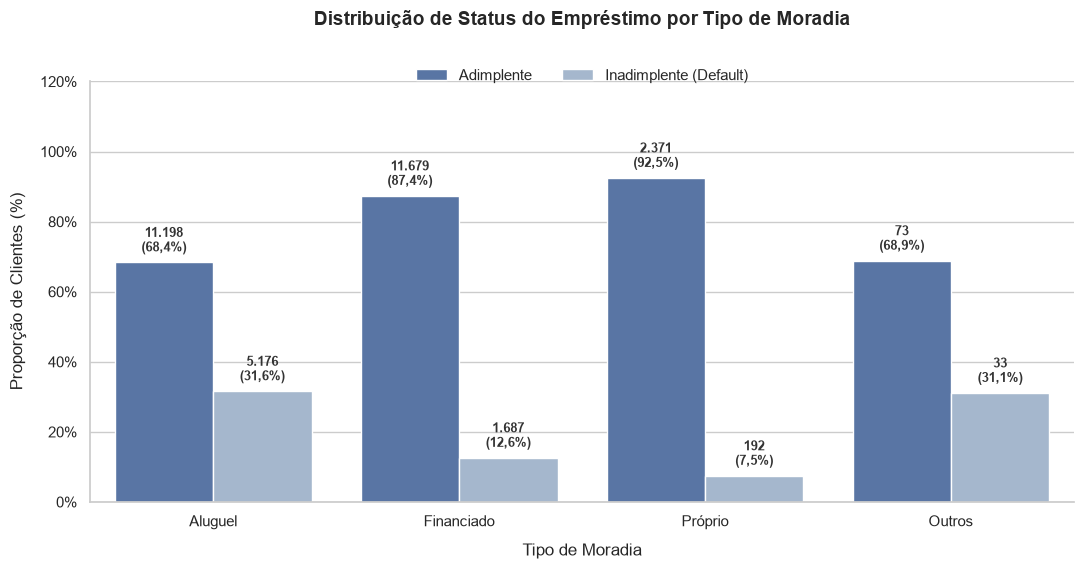

In [32]:
# ==============================================================================
# 6.9. VISUALIZAÇÃO BIVARIADA: STATUS DA OPERAÇÃO POR TIPO DE MORADIA
# ==============================================================================

def plotar_status_moradia(df: pd.DataFrame) -> None:
    """
    Gera um gráfico de barras agrupadas (grouped bar chart) para análise bivariada
    entre o tipo de propriedade residencial (home ownership) e a proporção
    de adimplência e inadimplência na carteira.

    Args:
        df (pd.DataFrame): Base de dados processada contendo os atributos alvo.
    """
    # Configuração do plano de fundo e dimensões da figura
    plt.figure(figsize=(11, 6.5))
    
    # Isolamento do dataframe para transformações estruturais locais
    df_temp = df.copy()
    
    # Mapeamento semântico do atributo categórico nominal para o idioma local (PT-BR)
    traducao_moradia = {
        'RENT': 'Aluguel',
        'MORTGAGE': 'Financiado',
        'OWN': 'Próprio',
        'OTHER': 'Outros'
    }
    df_temp['moradia_pt'] = df_temp['person_home_ownership'].map(traducao_moradia).fillna(df_temp['person_home_ownership'])
    
    # Agregação volumétrica absoluta por categoria de moradia e status da operação
    df_grouped = df_temp.groupby(
        ['moradia_pt', 'loan_status_label'], 
        observed=False
    ).size().reset_index(name='quantidade')
    
    # Computação da frequência relativa (percentual) intragrupo
    df_grouped['total_moradia'] = df_grouped.groupby('moradia_pt')['quantidade'].transform('sum')
    df_grouped['percentual'] = (df_grouped['quantidade'] / df_grouped['total_moradia']) * 100
    
    # Mapeamento vetorial de ordenação para plotagem categórica
    ordem_x = ['Aluguel', 'Financiado', 'Próprio', 'Outros']
    ordem_hue = ['Adimplente', 'Inadimplente (Default)']
    
    # Instanciação e parametrização do objeto gráfico agrupado
    ax = sns.barplot(
        x='moradia_pt', 
        y='percentual', 
        hue='loan_status_label', 
        data=df_grouped,
        order=ordem_x,
        hue_order=ordem_hue,
        palette=['#4C72B0', '#9EB6D4'], 
        dodge=True, 
        width=0.8
    )
    
    # Otimização visual e redução de ruído estrutural (Maximização do Data-Ink Ratio)
    sns.despine()
    
    # Formatação paramétrica do eixo Y para representação percentual absoluta
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:.0f}%"))
    
    # Escalonamento dinâmico do eixo Y para acomodação dos rótulos numéricos e anotações
    plt.ylim(0, df_grouped['percentual'].max() * 1.30)
    
    # Ordenação matricial estrita para garantir o alinhamento das anotações textuais com os polígonos (patches)
    df_grouped['moradia_pt'] = pd.Categorical(df_grouped['moradia_pt'], categories=ordem_x, ordered=True)
    df_grouped['loan_status_label'] = pd.Categorical(df_grouped['loan_status_label'], categories=ordem_hue, ordered=True)
    df_grouped = df_grouped.sort_values(by=['loan_status_label', 'moradia_pt']).reset_index(drop=True)
    
    # Iteração sobre a topologia das barras para injeção de volumetria e taxa de conversão
    for p, (_, row) in zip(ax.patches, df_grouped.iterrows()):
        height = p.get_height()
        if height > 0:
            # Formatação PT-BR unificada: Ponto para milhar (volumetria) e vírgula para decimal (percentual)
            vol_formatado = f"{int(row['quantidade']):,}".replace(',', '.')
            pct_formatado = f"{height:.1f}%".replace('.', ',')
            texto = f"{vol_formatado}\n({pct_formatado})"
            
            ax.annotate(
                texto, 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', 
                va='bottom', 
                fontsize=9, 
                fontweight='bold', 
                color='#333333', 
                xytext=(0, 5), 
                textcoords='offset points'
            )

    # Parametrização tipográfica de titulação e reposicionamento dinâmico da legenda externa
    plt.title('Distribuição de Status do Empréstimo por Tipo de Moradia', fontsize=14, fontweight='bold', pad=40)
    plt.legend(
        title='', 
        frameon=False, 
        loc='upper center', 
        bbox_to_anchor=(0.5, 1.06), 
        ncol=2, 
        fontsize=11
    )
    
    # Configuração dos eixos dimensionais espaciais
    plt.xlabel('Tipo de Moradia', fontsize=12, labelpad=10)
    plt.ylabel('Proporção de Clientes (%)', fontsize=12, labelpad=10)
    plt.xticks(rotation=0)
    
    # Otimização paramétrica da bounding box da figura para mitigar sobreposições topológicas
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()

# ==============================================================================
# Execução do Módulo Visual
# ==============================================================================
plotar_status_moradia(df_tratado)

Gráfico 10 - # Análise da distribuição de renda por status do empréstimo

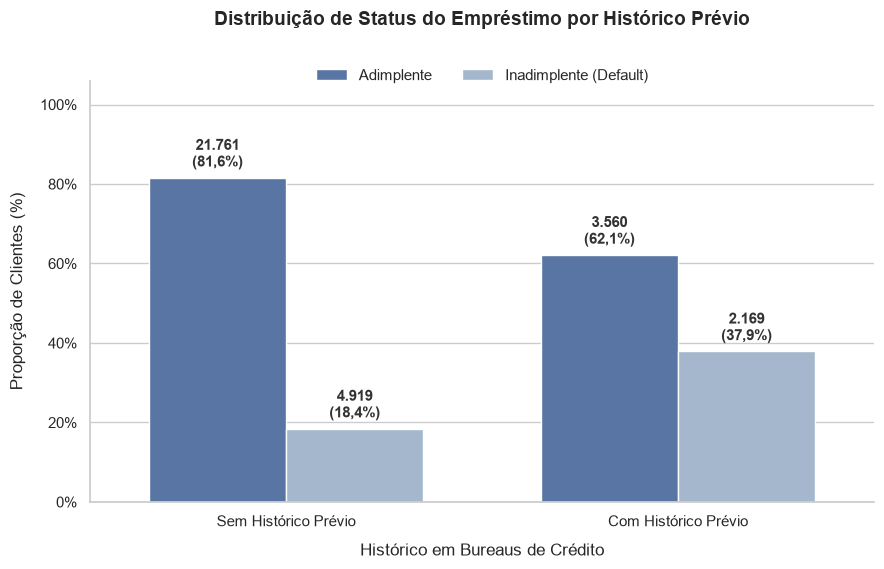

In [33]:
# ==============================================================================
# 6.10. VISUALIZAÇÃO BIVARIADA: STATUS DA OPERAÇÃO POR HISTÓRICO PRÉVIO
# ==============================================================================

def plotar_status_historico(df: pd.DataFrame) -> None:
    """
    Gera um gráfico de barras agrupadas (grouped bar chart) para análise bivariada
    entre a existência de histórico prévio de inadimplência em bureaus de crédito
    (default on file) e a proporção de adimplência na carteira.

    Args:
        df (pd.DataFrame): Base de dados processada contendo os atributos alvo.
    """
    # Configuração do plano de fundo e dimensões da figura
    plt.figure(figsize=(9, 6.5))
    
    # Isolamento do dataframe para transformações estruturais locais
    df_temp = df.copy()
    
    # Mapeamento semântico do atributo categórico booleano para o idioma local (PT-BR)
    df_temp['historico_pt'] = df_temp['cb_person_default_on_file'].map({
        'N': 'Sem Histórico Prévio',
        'Y': 'Com Histórico Prévio'
    }).fillna(df_temp['cb_person_default_on_file'])
    
    # Agregação volumétrica absoluta por histórico de crédito e status da operação
    df_grouped = df_temp.groupby(
        ['historico_pt', 'loan_status_label'], 
        observed=False
    ).size().reset_index(name='quantidade')
    
    # Computação da frequência relativa (percentual) intragrupo
    df_grouped['total_historico'] = df_grouped.groupby('historico_pt')['quantidade'].transform('sum')
    df_grouped['percentual'] = (df_grouped['quantidade'] / df_grouped['total_historico']) * 100
    
    # Mapeamento vetorial de ordenação para plotagem categórica
    ordem_x = ['Sem Histórico Prévio', 'Com Histórico Prévio']
    ordem_hue = ['Adimplente', 'Inadimplente (Default)']
    
    # Instanciação e parametrização do objeto gráfico agrupado
    ax = sns.barplot(
        x='historico_pt', 
        y='percentual', 
        hue='loan_status_label', 
        data=df_grouped,
        order=ordem_x,
        hue_order=ordem_hue,
        palette=['#4C72B0', '#9EB6D4'], 
        dodge=True, 
        width=0.7
    )
    
    # Otimização visual e redução de ruído estrutural (Maximização do Data-Ink Ratio)
    sns.despine()
    
    # Formatação paramétrica do eixo Y para representação percentual absoluta
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:.0f}%"))
    
    # Escalonamento dinâmico do eixo Y para acomodação dos rótulos numéricos e anotações
    plt.ylim(0, df_grouped['percentual'].max() * 1.30) 
    
    # Ordenação matricial estrita para garantir o alinhamento das anotações textuais com os polígonos
    df_grouped['historico_pt'] = pd.Categorical(df_grouped['historico_pt'], categories=ordem_x, ordered=True)
    df_grouped['loan_status_label'] = pd.Categorical(df_grouped['loan_status_label'], categories=ordem_hue, ordered=True)
    df_grouped = df_grouped.sort_values(by=['loan_status_label', 'historico_pt']).reset_index(drop=True)
    
    # Iteração sobre a topologia das barras para injeção de volumetria e taxa de conversão
    for p, (_, row) in zip(ax.patches, df_grouped.iterrows()):
        height = p.get_height()
        if height > 0:
            # Formatação PT-BR unificada: Ponto para milhar (volumetria) e vírgula para decimal (percentual)
            vol_formatado = f"{int(row['quantidade']):,}".replace(',', '.')
            pct_formatado = f"{height:.1f}%".replace('.', ',')
            texto = f"{vol_formatado}\n({pct_formatado})"
            
            ax.annotate(
                texto, 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', 
                va='bottom', 
                fontsize=11, 
                fontweight='bold', 
                color='#333333', 
                xytext=(0, 5), 
                textcoords='offset points'
            )

    # Parametrização tipográfica de titulação e repulsão vetorial do espaçamento interno (pad)
    plt.title('Distribuição de Status do Empréstimo por Histórico Prévio', fontsize=14, fontweight='bold', pad=40)
    
    # Reposicionamento dinâmico da legenda externa para mitigação de sobreposições
    plt.legend(
        title='', 
        frameon=False, 
        loc='upper center', 
        bbox_to_anchor=(0.5, 1.06), 
        ncol=2, 
        fontsize=11
    )
    
    # Configuração dos eixos dimensionais espaciais
    plt.xlabel('Histórico em Bureaus de Crédito', fontsize=12, labelpad=10)
    plt.ylabel('Proporção de Clientes (%)', fontsize=12, labelpad=10)
    plt.xticks(rotation=0)
    
    # Otimização paramétrica da bounding box da figura reservando área superior para legendas flutuantes
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()

# ==============================================================================
# Execução do Módulo Visual
# ==============================================================================
plotar_status_historico(df_tratado)

Gráfico 11 - Análise da inadimplência por grau de risco do empréstimo

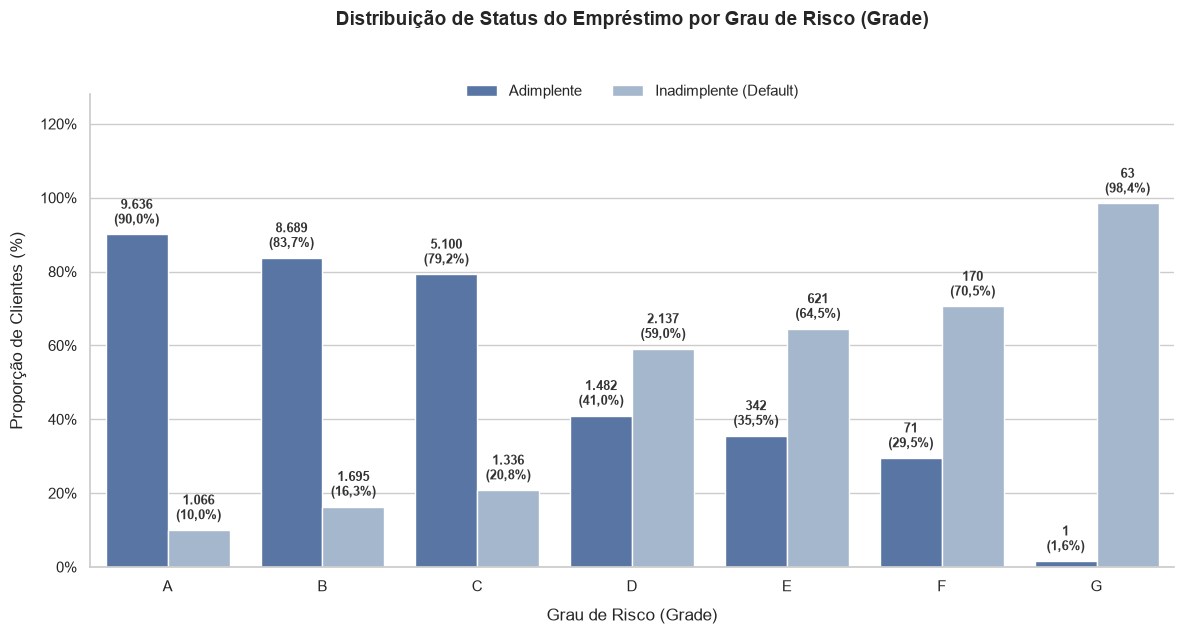

In [34]:
# ==============================================================================
# 6.11. VISUALIZAÇÃO BIVARIADA: STATUS DA OPERAÇÃO POR GRAU DE RISCO (GRADE)
# ==============================================================================

def plotar_status_grau_risco(df: pd.DataFrame) -> None:
    """
    Gera um gráfico de barras agrupadas (grouped bar chart) para análise bivariada
    entre o grau de risco de crédito (loan_grade) atribuído pela instituição e
    a proporção de adimplência/inadimplência. Inclui ajustes espaciais paramétricos
    para mitigação de sobreposição topológica entre títulos e legendas flutuantes.

    Args:
        df (pd.DataFrame): Base de dados processada contendo os atributos alvo.
    """
    # Configuração do plano de fundo e dimensões da figura
    plt.figure(figsize=(12, 6.5)) 
    
    # Isolamento do dataframe para transformações estruturais locais
    df_temp = df.copy()
    
    # Agregação volumétrica absoluta por grau de risco e status da operação
    df_grouped = df_temp.groupby(
        ['loan_grade', 'loan_status_label'], 
        observed=False
    ).size().reset_index(name='quantidade')
    
    # Computação da frequência relativa (percentual) intragrupo
    df_grouped['total_grade'] = df_grouped.groupby('loan_grade')['quantidade'].transform('sum')
    df_grouped['percentual'] = (df_grouped['quantidade'] / df_grouped['total_grade']) * 100
    
    # Mapeamento vetorial de ordenação categórica (ordem alfanumérica natural dos graus)
    ordem_x = sorted(df_temp['loan_grade'].dropna().unique())
    ordem_hue = ['Adimplente', 'Inadimplente (Default)']
    
    # Instanciação e parametrização do objeto gráfico agrupado
    ax = sns.barplot(
        x='loan_grade', 
        y='percentual', 
        hue='loan_status_label', 
        data=df_grouped,
        order=ordem_x,
        hue_order=ordem_hue,
        palette=['#4C72B0', '#9EB6D4'],
        dodge=True, 
        width=0.8
    )
    
    # Otimização visual e redução de ruído estrutural (Maximização do Data-Ink Ratio)
    sns.despine()
    
    # Formatação paramétrica do eixo Y para representação percentual absoluta
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:.0f}%"))
    
    # Escalonamento dinâmico do eixo Y para acomodação dos rótulos numéricos e anotações
    plt.ylim(0, df_grouped['percentual'].max() * 1.30) 
    
    # Ordenação matricial estrita para garantir o alinhamento das anotações textuais com os polígonos
    df_grouped['loan_grade'] = pd.Categorical(df_grouped['loan_grade'], categories=ordem_x, ordered=True)
    df_grouped['loan_status_label'] = pd.Categorical(df_grouped['loan_status_label'], categories=ordem_hue, ordered=True)
    df_grouped = df_grouped.sort_values(by=['loan_status_label', 'loan_grade']).reset_index(drop=True)
    
    # Iteração sobre a topologia das barras para injeção de volumetria e taxa de conversão
    for p, (_, row) in zip(ax.patches, df_grouped.iterrows()):
        height = p.get_height()
        if height > 0:
            # Formatação PT-BR unificada: Ponto para milhar (volumetria) e vírgula para decimal (percentual)
            vol_formatado = f"{int(row['quantidade']):,}".replace(',', '.')
            pct_formatado = f"{height:.1f}%".replace('.', ',')
            texto = f"{vol_formatado}\n({pct_formatado})"
            
            ax.annotate(
                texto, 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', 
                va='bottom', 
                fontsize=9.5, 
                fontweight='bold', 
                color='#333333', 
                xytext=(0, 5), 
                textcoords='offset points'
            )

    # Parametrização tipográfica de titulação e repulsão vetorial do espaçamento interno (pad)
    plt.title('Distribuição de Status do Empréstimo por Grau de Risco (Grade)', fontsize=14, fontweight='bold', pad=50)
    
    # Reposicionamento dinâmico da legenda externa para mitigação de sobreposições visuais
    plt.legend(
        title='', 
        frameon=False, 
        loc='upper center', 
        bbox_to_anchor=(0.5, 1.05), 
        ncol=2, 
        fontsize=11
    )
    
    # Configuração dos eixos dimensionais espaciais
    plt.xlabel('Grau de Risco (Grade)', fontsize=12, labelpad=10)
    plt.ylabel('Proporção de Clientes (%)', fontsize=12, labelpad=10)
    plt.xticks(rotation=0)
    
    # Otimização paramétrica da bounding box da figura
    plt.tight_layout()
    plt.show()

# ==============================================================================
# Execução do Módulo Visual
# ==============================================================================
plotar_status_grau_risco(df_tratado)

Gráfico 12 – Distribuição da Idade por Status do Empréstimo

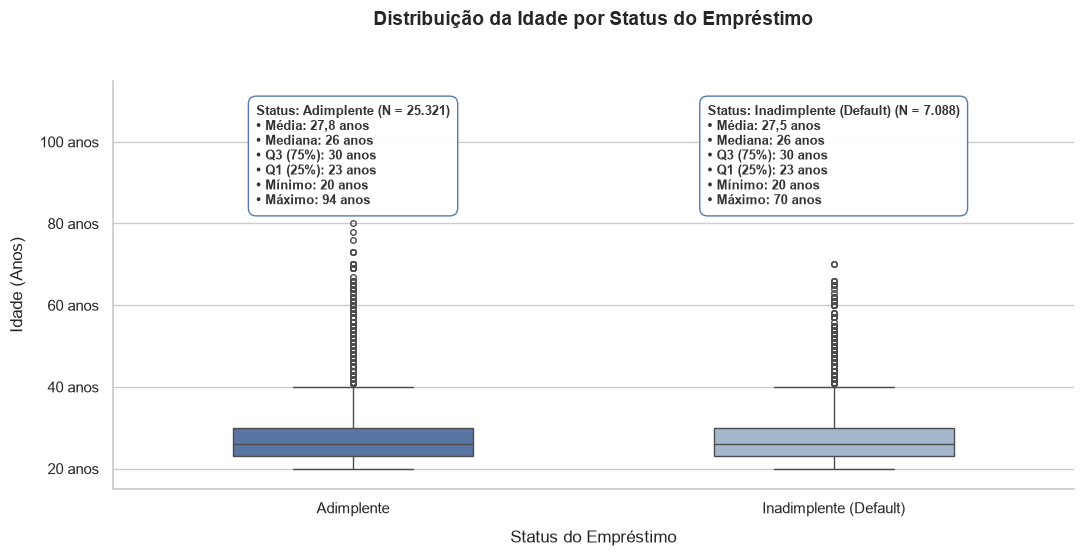

In [35]:
# ==============================================================================
# 6.12. VISUALIZAÇÃO BIVARIADA: DISTRIBUIÇÃO DA IDADE POR STATUS (BOXPLOT)
# ==============================================================================

def plotar_idade_por_status(df: pd.DataFrame) -> None:
    """
    Gera um diagrama de caixa (boxplot) relacionando a idade do requerente (person_age)
    com o status final da operação de crédito. Inclui a renderização de anotações
    textuais responsivas contendo métricas de estatística descritiva e tendência central.

    Args:
        df (pd.DataFrame): Base de dados processada contendo os atributos alvo.
    """
    # Configuração do plano de fundo e dimensões paramétricas da figura
    plt.figure(figsize=(11, 6.5))

    # Isolamento do dataframe para aplicação de transformações estruturais locais
    df_temp = df.copy()
    
    # Mapeamento semântico condicional para o atributo categórico da variável alvo
    if 'loan_status' in df_temp.columns:
        df_temp['loan_status_label'] = df_temp['loan_status'].map({
            0: 'Adimplente', 
            1: 'Inadimplente (Default)'
        })
        
    # Definição matricial estrita das classes operacionais
    ordem_classes = ['Adimplente', 'Inadimplente (Default)']
    
    # Instanciação e parametrização do diagrama de caixa bidimensional
    ax = sns.boxplot(
        x='loan_status_label', 
        y='person_age', 
        hue='loan_status_label',
        legend=False,
        data=df_temp, 
        order=ordem_classes,
        palette=['#4C72B0', '#9EB6D4'], 
        width=0.5, 
        fliersize=4
    )
    
    # Otimização visual e redução de ruído não-essencial (Maximização do Data-Ink Ratio)
    sns.despine()

    # Escalonamento paramétrico do limite vertical para supressão de distorções e acomodação de rótulos
    limite_y_max = 115 
    plt.ylim(15, limite_y_max)

    # Formatação contínua do eixo Y para explicitação estrita da unidade de medida (anos)
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, pos: f"{int(x)} anos")
    )

    # Definição do ponto de ancoragem vertical escalar para as caixas de estatísticas descritivas
    ancora_texto_y = limite_y_max * 0.95

    # Iteração sobre as topologias de classe para extração das métricas de tendência central e dispersão
    for i, status in enumerate(ordem_classes):
        subset = df_temp[df_temp['loan_status_label'] == status]['person_age'].dropna()
        
        # Formatação PT-BR unificada: Ponto para milhar (volumetria) e vírgula para decimal (idade média)
        vol_formatado = f"{len(subset):,}".replace(",", ".")
        media_formatada = f"{subset.mean():.1f}".replace(".", ",")
        
        # Estruturação geométrica e formatação do report descritivo por classe
        texto_resumo = (
            f"Status: {status} (N = {vol_formatado})\n"
            f"• Média: {media_formatada} anos\n"
            f"• Mediana: {subset.median():.0f} anos\n"
            f"• Q3 (75%): {subset.quantile(0.75):.0f} anos\n"
            f"• Q1 (25%): {subset.quantile(0.25):.0f} anos\n"
            f"• Mínimo: {subset.min():.0f} anos\n"
            f"• Máximo: {subset.max():.0f} anos"
        )
        
        # Inserção da caixa delimitadora (bounding box) contendo o sumário descritivo
        ax.text(
            x=i, 
            y=ancora_texto_y, 
            s=texto_resumo,
            ha='center', 
            va='top', 
            multialignment='left', 
            fontsize=9.5, 
            fontweight='bold', 
            color='#333333',
            bbox=dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor="#4C72B0", alpha=0.95)
        )

    # Parametrização tipográfica de titulação e repulsão vetorial do espaçamento interno (pad)
    plt.title('Distribuição da Idade por Status do Empréstimo', fontsize=14, fontweight='bold', pad=40)
    plt.xlabel('Status do Empréstimo', fontsize=12, labelpad=10)
    plt.ylabel('Idade (Anos)', fontsize=12, labelpad=10)

    # Otimização paramétrica da bounding box da figura para mitigar sobreposições topológicas (reserva de margem superior)
    plt.tight_layout(rect=[0, 0, 1, 0.88]) 
    plt.show()

# ==============================================================================
# Execução do Módulo Visual
# ==============================================================================
plotar_idade_por_status(df_tratado)

Gráfico 13 - Taxa de Inadimplência por Faixa Etária

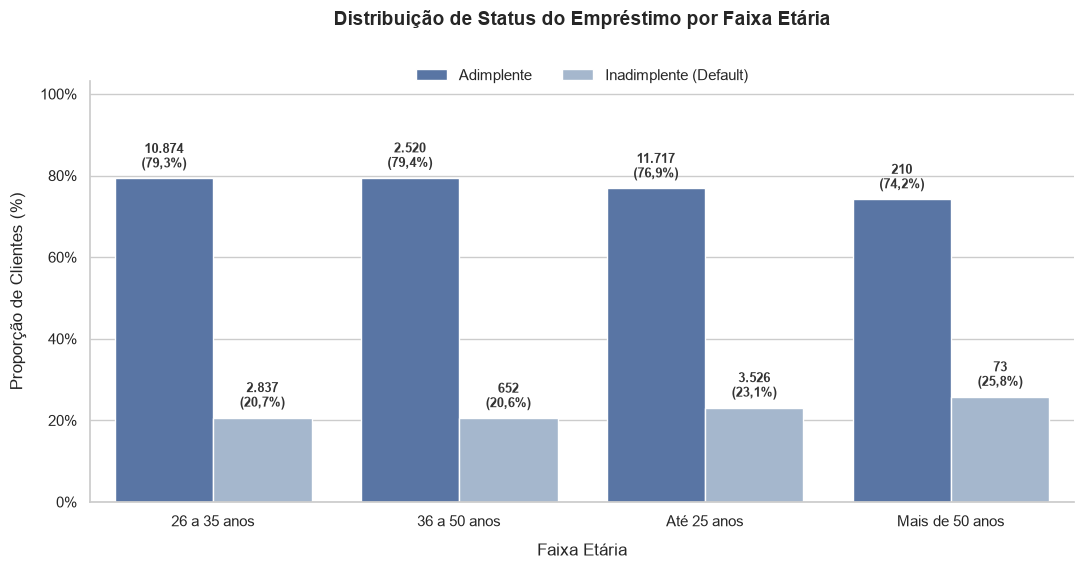

In [36]:
# ==============================================================================
# 6.13. VISUALIZAÇÃO BIVARIADA: STATUS DA OPERAÇÃO POR FAIXA ETÁRIA
# ==============================================================================

def plotar_status_faixa_etaria(df: pd.DataFrame) -> None:
    """
    Gera um gráfico de barras agrupadas (grouped bar chart) para análise bivariada
    entre a faixa etária do cliente (age_group) e a proporção de adimplência/inadimplência.
    Inclui ajustes espaciais paramétricos para mitigação de sobreposição topológica
    entre a titulação primária e a legenda.

    Args:
        df (pd.DataFrame): Base de dados processada contendo os atributos alvo.
    """
    # Configuração do plano de fundo e dimensões da figura
    plt.figure(figsize=(11, 6.5))
    
    # Isolamento do dataframe para transformações estruturais locais
    df_temp = df.copy()
    
    # Agregação volumétrica absoluta por faixa etária e status da operação
    df_grouped = df_temp.groupby(
        ['age_group', 'loan_status_label'], 
        observed=False
    ).size().reset_index(name='quantidade')
    
    # Computação da frequência relativa (percentual) intragrupo
    df_grouped['total_faixa'] = df_grouped.groupby('age_group')['quantidade'].transform('sum')
    df_grouped['percentual'] = (df_grouped['quantidade'] / df_grouped['total_faixa']) * 100
    
    # Mapeamento vetorial de ordenação categórica
    ordem_x = sorted(df_temp['age_group'].dropna().unique())
    ordem_hue = ['Adimplente', 'Inadimplente (Default)']
    
    # Instanciação e parametrização do objeto gráfico agrupado
    ax = sns.barplot(
        x='age_group', 
        y='percentual', 
        hue='loan_status_label', 
        data=df_grouped,
        order=ordem_x,
        hue_order=ordem_hue,
        palette=['#4C72B0', '#9EB6D4'], 
        dodge=True, 
        width=0.8
    )
    
    # Otimização visual e redução de ruído estrutural (Maximização do Data-Ink Ratio)
    sns.despine()
    
    # Formatação paramétrica do eixo Y para representação percentual absoluta
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:.0f}%"))
    
    # Escalonamento dinâmico do eixo Y para acomodação dos rótulos numéricos e anotações
    plt.ylim(0, df_grouped['percentual'].max() * 1.30)
    
    # Ordenação matricial estrita para garantir o alinhamento das anotações textuais com os polígonos
    df_grouped['age_group'] = pd.Categorical(df_grouped['age_group'], categories=ordem_x, ordered=True)
    df_grouped['loan_status_label'] = pd.Categorical(df_grouped['loan_status_label'], categories=ordem_hue, ordered=True)
    df_grouped = df_grouped.sort_values(by=['loan_status_label', 'age_group']).reset_index(drop=True)
    
    # Iteração sobre a topologia das barras para injeção de volumetria e taxa de conversão
    for p, (_, row) in zip(ax.patches, df_grouped.iterrows()):
        height = p.get_height()
        if height > 0:
            # Formatação PT-BR unificada: Ponto para milhar (volumetria) e vírgula para decimal (percentual)
            vol_formatado = f"{int(row['quantidade']):,}".replace(',', '.')
            pct_formatado = f"{height:.1f}%".replace('.', ',')
            texto = f"{vol_formatado}\n({pct_formatado})"
            
            ax.annotate(
                texto, 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', 
                va='bottom', 
                fontsize=9, 
                fontweight='bold', 
                color='#333333', 
                xytext=(0, 5), 
                textcoords='offset points'
            )

    # Parametrização tipográfica de titulação e repulsão vetorial do espaçamento interno (pad)
    plt.title('Distribuição de Status do Empréstimo por Faixa Etária', fontsize=14, fontweight='bold', pad=40)
    
    # Reposicionamento dinâmico da legenda externa para mitigação de sobreposições visuais
    plt.legend(
        title='', 
        frameon=False, 
        loc='upper center', 
        bbox_to_anchor=(0.5, 1.06), 
        ncol=2, 
        fontsize=11
    )
    
    # Configuração dos eixos dimensionais espaciais
    plt.xlabel('Faixa Etária', fontsize=12, labelpad=10)
    plt.ylabel('Proporção de Clientes (%)', fontsize=12, labelpad=10)
    plt.xticks(rotation=0)
    
    # Otimização paramétrica da bounding box da figura reservando área superior exclusiva para a titulação
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()

# ==============================================================================
# Execução do Módulo Visual
# ==============================================================================
plotar_status_faixa_etaria(df_tratado)

Gráfico 14 – Relação entre Comprometimento de Renda (DTI) e Inadimplência

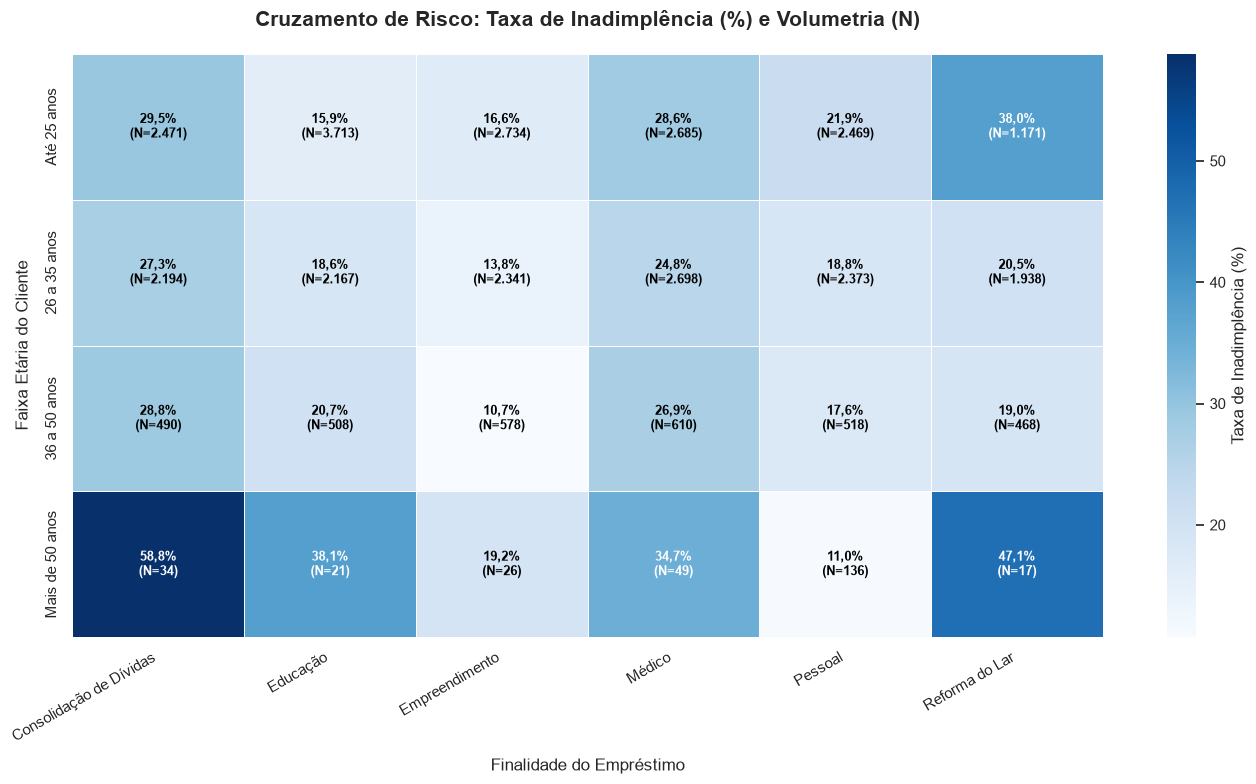

In [37]:
# ==============================================================================
# 6.14. VISUALIZAÇÃO MULTIVARIADA: MAPA DE CALOR DE RISCO (HEATMAP)
# ==============================================================================

def plotar_heatmap_risco(df: pd.DataFrame) -> None:
    """
    Gera um mapa de calor (heatmap) bidimensional para analisar a taxa de
    inadimplência segmentada simultaneamente por faixa etária e finalidade
    do crédito. Renderiza anotações customizadas contendo a taxa de conversão
    (risco) e a volumetria absoluta (N) por célula.

    Args:
        df (pd.DataFrame): Base de dados processada contendo os atributos alvo.
    """
    # Configuração do plano de fundo e dimensões da figura matricial
    plt.figure(figsize=(14, 8))
    
    # Isolamento do dataframe para transformações estruturais locais
    df_temp = df.copy()
    
    # Mapeamento semântico do atributo categórico nominal para o idioma local (PT-BR)
    traducao_intent = {
        'PERSONAL': 'Pessoal', 
        'EDUCATION': 'Educação', 
        'MEDICAL': 'Médico',
        'VENTURE': 'Empreendimento', 
        'HOMEIMPROVEMENT': 'Reforma do Lar',
        'DEBTCONSOLIDATION': 'Consolidação de Dívidas'
    }
    df_temp['loan_intent_pt'] = df_temp['loan_intent'].map(traducao_intent).fillna(df_temp['loan_intent'])
    
    # Computação da matriz de agregação para a métrica de risco (Taxa Média de Inadimplência)
    pivot_taxa = df_temp.pivot_table(
        index='age_group', 
        columns='loan_intent_pt', 
        values='loan_status', 
        aggfunc='mean',
        observed=False
    ) * 100
    
    # Computação da matriz de agregação secundária para a volumetria absoluta (Contagem - N)
    pivot_volume = df_temp.pivot_table(
        index='age_group', 
        columns='loan_intent_pt', 
        values='loan_status', 
        aggfunc='count',
        observed=False
    )
    
    # Instanciação e parametrização do objeto gráfico matricial
    ax = sns.heatmap(
        pivot_taxa, 
        annot=False, 
        cmap='Blues', 
        cbar_kws={'label': 'Taxa de Inadimplência (%)'},
        linewidths=.5,
        linecolor='white'
    )
    
    # Iteração sobre os eixos matriciais para injeção e formatação PT-BR das anotações textuais
    for i in range(len(pivot_taxa)):
        for j in range(len(pivot_taxa.columns)):
            taxa = pivot_taxa.iloc[i, j]
            volume = pivot_volume.iloc[i, j]
            
            # Controle de fluxo defensivo para células esparsas (NaN)
            if pd.isna(taxa) or pd.isna(volume):
                continue
            
            # Formatação PT-BR unificada: Ponto para milhar (volumetria) e vírgula para decimal (taxa)
            taxa_formatada = f"{taxa:.1f}%".replace('.', ',')
            vol_formatado = f"{int(volume):,}".replace(',', '.')
            texto_celula = f"{taxa_formatada}\n(N={vol_formatado})"
            
            # Ajuste dinâmico de contraste topológico para garantir legibilidade tipográfica
            cor_texto = 'white' if taxa > 30 else 'black'
            
            # Renderização das anotações flutuantes no centro geométrico de cada célula
            ax.text(
                j + 0.5, 
                i + 0.5, 
                texto_celula, 
                ha='center', 
                va='center', 
                color=cor_texto, 
                fontweight='bold', 
                fontsize=9
            )

    # Parametrização tipográfica de titulação e reposicionamento espacial dos rótulos
    plt.title('Cruzamento de Risco: Taxa de Inadimplência (%) e Volumetria (N)', fontsize=15, fontweight='bold', pad=20)
    plt.xlabel('Finalidade do Empréstimo', fontsize=12, labelpad=10)
    plt.ylabel('Faixa Etária do Cliente', fontsize=12, labelpad=10)
    
    # Otimização paramétrica da rotação dos rótulos em X e bounding box da figura
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

# ==============================================================================
# Execução do Módulo Visual
# ==============================================================================
plotar_heatmap_risco(df_tratado)